Episode 0: Actor Loss = 0.3508407473564148, Critic Loss = 506.3638000488281, Average Reward = 0.52
Episode 10: Actor Loss = 0.34179913997650146, Critic Loss = 379.23260498046875, Average Reward = 0.47
Episode 20: Actor Loss = 0.2312363088130951, Critic Loss = 424.7640380859375, Average Reward = 0.49
Episode 30: Actor Loss = 0.32656392455101013, Critic Loss = 369.2762451171875, Average Reward = 0.47
Episode 40: Actor Loss = 0.4098254144191742, Critic Loss = 410.6357116699219, Average Reward = 0.49
Episode 50: Actor Loss = 0.3658185601234436, Critic Loss = 375.9603271484375, Average Reward = 0.50
Episode 60: Actor Loss = 0.28868159651756287, Critic Loss = 413.09405517578125, Average Reward = 0.52
Episode 70: Actor Loss = 0.3282228112220764, Critic Loss = 379.1361389160156, Average Reward = 0.51
Episode 80: Actor Loss = 0.34277060627937317, Critic Loss = 409.46258544921875, Average Reward = 0.52
Episode 90: Actor Loss = 0.3720813989639282, Critic Loss = 379.6297912597656, Average Reward =

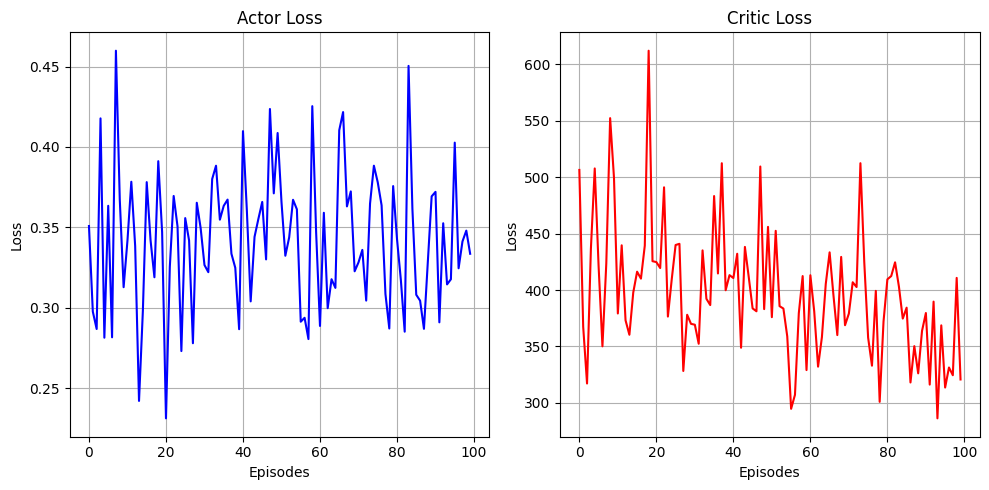

Average evaluation reward (Actor-Critic): 50.19198585510254
Average evaluation reward (PID Control): 5.0059763932228085
t-statistic: 164.30395159683573
p-value: 1.2941422819141748e-213
There is a significant difference in performance between the actor-critic model and PID control.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


# Actor-Critic Neural Network
class ActorCriticNetwork(nn.Module):
    def __init__(self, state_size, action_size, learning_rate=0.001):
        super(ActorCriticNetwork, self).__init__()
        # Actor network
        self.actor_fc1 = nn.Linear(state_size, 64)
        self.actor_fc2 = nn.Linear(64, action_size)
        # Critic network
        self.critic_fc1 = nn.Linear(state_size, 64)
        self.critic_fc2 = nn.Linear(64, 1)
        # Optimizer
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, state):
        # Actor network
        actor_x = torch.relu(self.actor_fc1(state))
        action_probs = torch.softmax(self.actor_fc2(actor_x), dim=-1)
        # Critic network
        critic_x = torch.relu(self.critic_fc1(state))
        state_value = self.critic_fc2(critic_x)
        return action_probs, state_value

    def train_step(self, states, actions, returns, advantages):
        # Calculate actor and critic losses
        action_probs, state_values = self.forward(states)
        log_probs = torch.log(action_probs)
        selected_log_probs = torch.sum(log_probs * actions, dim=-1)
        actor_loss = -torch.mean(selected_log_probs * advantages)
        critic_loss = nn.MSELoss()(state_values.squeeze(), returns)

        # Backpropagation
        self.optimizer.zero_grad()
        actor_loss.backward()
        critic_loss.backward()
        self.optimizer.step()

        return actor_loss.item(), critic_loss.item()


# Environment Helper function (Replace with your environment)
class Environment:
    def __init__(self):
        self.state_size = 4  # Example state size
        self.action_size = 2  # Example action size

    def reset(self):
        return torch.tensor(np.random.rand(self.state_size), dtype=torch.float32)

    def step(self, action):
        next_state = torch.tensor(np.random.rand(self.state_size), dtype=torch.float32)
        reward = torch.tensor(np.random.rand(), dtype=torch.float32)
        done = False  # Example termination condition
        return next_state, reward, done

def plot_training_curves(actor_losses, critic_losses):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(actor_losses, label='Actor Loss', color='blue')
    plt.title('Actor Loss')
    plt.xlabel('Episodes')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(critic_losses, label='Critic Loss', color='red')
    plt.title('Critic Loss')
    plt.xlabel('Episodes')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Training
environment = Environment()
actor_critic = ActorCriticNetwork(state_size=environment.state_size, action_size=environment.action_size)
num_episodes = 100
actor_losses = []
critic_losses = []

for episode in range(num_episodes):
    states = []
    actions = []
    rewards = []
    next_states = []
    total_episode_reward=0
    state = environment.reset()
    max_steps_per_episode=100
    for t in range(max_steps_per_episode):
        action_probs, _ = actor_critic.forward(state)
        action = torch.multinomial(action_probs, 1)
        next_state, reward, done = environment.step(action)

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_state)
        total_episode_reward+=reward

        state = next_state

        if done:
            break

    returns = compute_returns(rewards)
    next_state_values = actor_critic.forward(torch.stack(next_states))[1]
    advantages = compute_advantages(rewards, next_state_values)

    actor_loss, critic_loss = actor_critic.train_step(torch.stack(states), torch.stack(actions), returns, advantages)
    actor_losses.append(actor_loss)
    critic_losses.append(critic_loss)
    average_episode_reward = total_episode_reward / len(rewards)
    # print(f"Episode {episode + 1}: Average Reward = {average_episode_reward:.2f}")

    # Print average reward every few episodes
    if episode % 10 == 0:
        print(f"Episode {episode}: Actor Loss = {actor_loss}, Critic Loss = {critic_loss}, Average Reward = {average_episode_reward:.2f}")

# Plot training curves
plot_training_curves(actor_losses, critic_losses)

# Compare with Baseline Methods
# Define baseline methods (e.g., PID control)
# Evaluate the trained actor-critic model
def evaluate_policy(actor, environment, num_episodes=100, max_steps_per_episode=100):
    total_rewards = []
    for _ in range(num_episodes):
        state = environment.reset()
        episode_reward = 0
        for _ in range(max_steps_per_episode):
            action_probs = actor.forward(state)
            action_probs_concatenated = torch.cat(action_probs, dim=0)  # Concatenate tensors along the first dimension
            action = torch.argmax(action_probs_concatenated)  # Use argmax on the concatenated tensor
            next_state, reward, done = environment.step(action)
            episode_reward += reward
            state = next_state
            if done:
                break
        total_rewards.append(episode_reward.item())
    return total_rewards

def pid_controller(state):
    # Example PID controller parameters
    kp = 0.5
    ki = 0.1
    kd = 0.01
    desired_output = 5.0
    integral_term = 0  # Initialize integral term to zero
    prev_error = 0     # Initialize previous error to zero
    action = 0
    # Compute error (e.g., difference between desired and actual output)
    error = desired_output - state

    # Integral term (accumulated error)
    integral_term += error

    # Derivative term (rate of change of error)
    derivative_term = error - prev_error
    prev_error = error

    # Compute control action using PID formula
    action = kp * error + ki * integral_term + kd * derivative_term

    return action


def pid_control(environment, num_episodes=100, max_steps_per_episode=10):
    total_rewards = []
    for _ in range(num_episodes):
        state = environment.reset()
        episode_reward = 0
        for _ in range(max_steps_per_episode):
            # Example PID control implementation
            action = pid_controller(state)  # Use PID controller to compute action
            next_state, reward, done = environment.step(action)
            episode_reward += reward
            state = next_state
            if done:
                break
        total_rewards.append(episode_reward.item())
    return total_rewards


evaluation_rewards_actor_critic = evaluate_policy(actor_critic, environment)
average_evaluation_reward_actor_critic = sum(evaluation_rewards_actor_critic) / len(evaluation_rewards_actor_critic)

# Evaluate PID control
pid_rewards = pid_control(environment)
average_pid_reward = sum(pid_rewards) / len(pid_rewards)

# Compare performance
print("Average evaluation reward (Actor-Critic):", average_evaluation_reward_actor_critic)
print("Average evaluation reward (PID Control):", average_pid_reward)

# Perform statistical analysis (e.g., t-test) to compare the performance of the actor-critic model with PID control
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(evaluation_rewards_actor_critic, pid_rewards)
print("t-statistic:", t_stat)
print("p-value:", p_value)

# Interpret the results of the statistical test to determine if there is a significant difference in performance
if p_value < 0.05:
    print("There is a significant difference in performance between the actor-critic model and PID control.")
else:
    print("There is no significant difference in performance between the actor-critic model and PID control.")


Episode 0: Actor Loss = 0.25229811668395996, Critic Loss = 476.62457275390625, Average Reward = 0.53, Entropy = 0.6913
Episode 10: Actor Loss = 0.2860132157802582, Critic Loss = 373.83551025390625, Average Reward = 0.48, Entropy = 0.6931
Episode 20: Actor Loss = 0.31751763820648193, Critic Loss = 407.7041320800781, Average Reward = 0.51, Entropy = 0.6931
Episode 30: Actor Loss = 0.29870888590812683, Critic Loss = 321.3358459472656, Average Reward = 0.44, Entropy = 0.6931
Episode 40: Actor Loss = 0.3069210648536682, Critic Loss = 449.5758056640625, Average Reward = 0.52, Entropy = 0.6931
Episode 50: Actor Loss = 0.2700590193271637, Critic Loss = 330.767578125, Average Reward = 0.45, Entropy = 0.6931
Episode 60: Actor Loss = 0.35941097140312195, Critic Loss = 430.60186767578125, Average Reward = 0.52, Entropy = 0.6931
Episode 70: Actor Loss = 0.32391056418418884, Critic Loss = 355.74920654296875, Average Reward = 0.48, Entropy = 0.6931
Episode 80: Actor Loss = 0.2626386880874634, Critic 

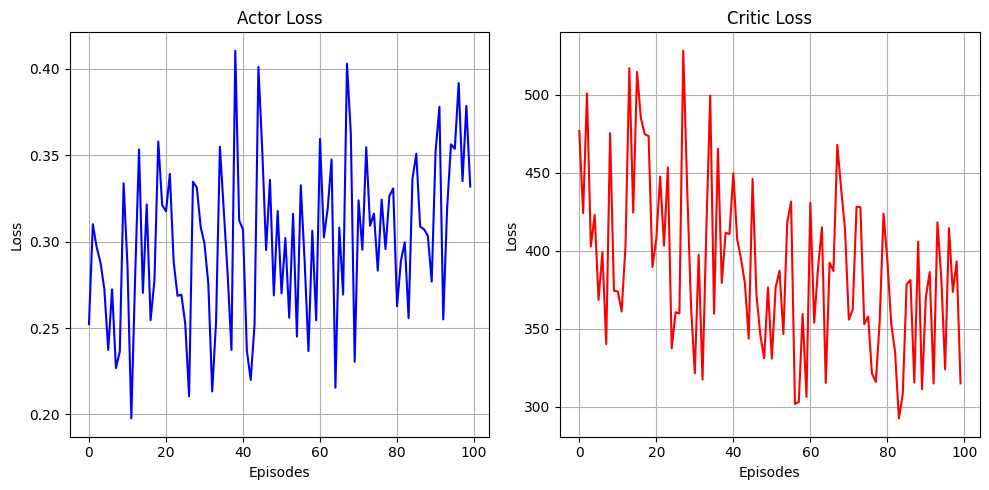

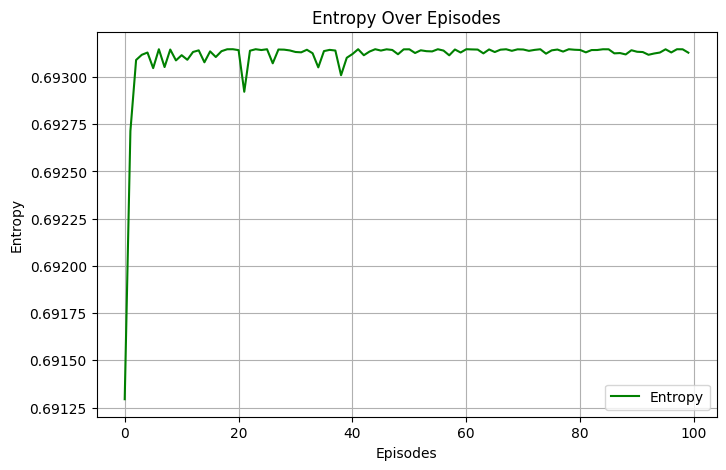

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


# Actor-Critic Neural Network with Entropy Regularization
class ActorCriticNetwork(nn.Module):
    def __init__(self, state_size, action_size, learning_rate=0.001, entropy_weight=0.01):
        super(ActorCriticNetwork, self).__init__()
        # Actor network
        self.actor_fc1 = nn.Linear(state_size, 64)
        self.actor_fc2 = nn.Linear(64, action_size)
        # Critic network
        self.critic_fc1 = nn.Linear(state_size, 64)
        self.critic_fc2 = nn.Linear(64, 1)
        # Optimizer
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)
        # Entropy weight
        self.entropy_weight = entropy_weight

    def forward(self, state):
        # Actor network
        actor_x = torch.relu(self.actor_fc1(state))
        action_probs = torch.softmax(self.actor_fc2(actor_x), dim=-1)
        # Critic network
        critic_x = torch.relu(self.critic_fc1(state))
        state_value = self.critic_fc2(critic_x)
        return action_probs, state_value

    def train_step(self, states, actions, returns, advantages):
        # Calculate actor and critic losses
        action_probs, state_values = self.forward(states)
        log_probs = torch.log(action_probs)
        selected_log_probs = torch.sum(log_probs * actions, dim=-1)
        entropy = -torch.sum(action_probs * log_probs, dim=-1)  # Entropy calculation
        actor_loss = -(torch.mean(selected_log_probs * advantages) + self.entropy_weight * torch.mean(entropy))  # Actor loss with entropy regularization
        critic_loss = nn.MSELoss()(state_values.squeeze(), returns)

        # Backpropagation
        self.optimizer.zero_grad()
        actor_loss.backward()
        critic_loss.backward()
        self.optimizer.step()

        return actor_loss.item(), critic_loss.item()


# Environment Helper function (Replace with your environment)
class Environment:
    def __init__(self):
        self.state_size = 4  # Example state size
        self.action_size = 2  # Example action size

    def reset(self):
        return torch.tensor(np.random.rand(self.state_size), dtype=torch.float32)

    def step(self, action):
        next_state = torch.tensor(np.random.rand(self.state_size), dtype=torch.float32)
        reward = torch.tensor(np.random.rand(), dtype=torch.float32)
        done = False  # Example termination condition
        return next_state, reward, done

def plot_training_curves(actor_losses, critic_losses):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(actor_losses, label='Actor Loss', color='blue')
    plt.title('Actor Loss')
    plt.xlabel('Episodes')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(critic_losses, label='Critic Loss', color='red')
    plt.title('Critic Loss')
    plt.xlabel('Episodes')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Training
# Training with Exploration-Exploitation Balance
# Training with Exploration-Exploitation Balance and Entropy Analysis
environment = Environment()
actor_critic = ActorCriticNetwork(state_size=environment.state_size, action_size=environment.action_size, entropy_weight=0.1)  # Starting with a higher entropy weight
num_episodes = 100
actor_losses = []
critic_losses = []
entropy_values = []

initial_entropy_weight = 0.1
final_entropy_weight = 0.01
entropy_weight_decay = (initial_entropy_weight - final_entropy_weight) / num_episodes

for episode in range(num_episodes):
    states = []
    actions = []
    rewards = []
    next_states = []
    total_episode_reward = 0
    state = environment.reset()
    max_steps_per_episode = 100

    # Update entropy weight
    actor_critic.entropy_weight -= entropy_weight_decay

    for t in range(max_steps_per_episode):
        action_probs, _ = actor_critic.forward(state)
        action = torch.multinomial(action_probs, 1)
        next_state, reward, done = environment.step(action)

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_state)
        total_episode_reward += reward

        state = next_state

        if done:
            break

    returns = compute_returns(rewards)
    next_state_values = actor_critic.forward(torch.stack(next_states))[1]
    advantages = compute_advantages(rewards, next_state_values)

    actor_loss, critic_loss = actor_critic.train_step(torch.stack(states), torch.stack(actions), returns, advantages)
    actor_losses.append(actor_loss)
    critic_losses.append(critic_loss)
    average_episode_reward = total_episode_reward / len(rewards)

    # Calculate entropy and record its value
    action_probs, _ = actor_critic.forward(state)
    entropy = -torch.sum(action_probs * torch.log(action_probs), dim=-1).mean().item()
    entropy_values.append(entropy)

    if episode % 10 == 0:
        print(f"Episode {episode}: Actor Loss = {actor_loss}, Critic Loss = {critic_loss}, Average Reward = {average_episode_reward:.2f}, Entropy = {entropy:.4f}")

# Plot training curves
plot_training_curves(actor_losses, critic_losses)

# Plot entropy graph
plt.figure(figsize=(8, 5))
plt.plot(range(num_episodes), entropy_values, label='Entropy', color='green')
plt.title('Entropy Over Episodes')
plt.xlabel('Episodes')
plt.ylabel('Entropy')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

# Actor Neural Network
# class ActorNetwork(nn.Module):
#     def __init__(self, state_size, action_size, learning_rate):
#         super(ActorNetwork, self).__init__()
#         self.fc1 = nn.Linear(state_size, 64)
#         self.fc2 = nn.Linear(64, action_size)
#         self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)
class ActorNetwork(nn.Module):
    def __init__(self, state_size, action_size, learning_rate):
        super(ActorNetwork, self).__init__()
        self.state_size = state_size
        self.action_size = action_size  # Define action_size attribute
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, action_size)
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        action_probs = torch.softmax(self.fc2(x), dim=-1)
        return action_probs

    def train_step(self, states, actions, advantages):
        self.optimizer.zero_grad()
        action_probs = self.forward(states)
        log_probs = torch.log(action_probs)
        selected_log_probs = torch.sum(log_probs * actions, dim=-1)
        actor_loss = -torch.mean(selected_log_probs * advantages)
        actor_loss.backward()
        self.optimizer.step()

        return actor_loss  # Return actor loss

# ------------------------------------------------------------------------
# Critic Neural Network
class CriticNetwork(nn.Module):
    def __init__(self, state_size, learning_rate):
        super(CriticNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        state_value = self.fc2(x)
        return state_value

    def train_step(self, states, targets):
        self.optimizer.zero_grad()
        predicted_values = self.forward(states)
        critic_loss = nn.MSELoss()(predicted_values.squeeze(), targets)
        critic_loss.backward()
        self.optimizer.step()

        return critic_loss  # Return critic loss

# ------------------------------------------------------------------------
# Environment Helper function
class DCDCEnvironment:
    def __init__(self):
        self.state_size = 2  # Example state size
        self.action_size = 3  # Example action size

    def reset(self):
        return torch.tensor(np.random.rand(self.state_size), dtype=torch.float32)

    def step(self, action):
        # Example step function, you would replace this with your actual environment dynamics
        next_state = torch.tensor(np.random.rand(self.state_size), dtype=torch.float32)
        reward = torch.tensor(np.random.rand(), dtype=torch.float32)
        done = False  # Example termination condition
        return next_state, reward, done

# ------------------------------------------------------------------------
# Epsilon Greedy Policy
class EpsilonGreedyPolicy:
    def __init__(self, epsilon):
        self.epsilon = epsilon
        self.action_selections = []  # Track action selections

    def select_action(self, actor, state):
        if random.random() < self.epsilon:
            # Explore: take a random action
            action = random.randrange(actor.action_size)
        else:
            # Exploit: choose the action with the highest estimated value
            action_probs = actor.forward(state)
            action = torch.argmax(action_probs).item()
        self.action_selections.append(action)  # Track action selection
        return action

# ------------------------------------------------------------------------
# Training
def train_with_epsilon_greedy(actor, critic, environment, policy, num_episodes=1000):
    actor_losses = []
    critic_losses = []

    for episode in range(num_episodes):
        state = environment.reset()
        states = []
        actions = []
        rewards = []
        next_states = []

        total_episode_reward = 0  # Track total reward for the current episode

        done = False
        while not done:
            action = policy.select_action(actor, state)
            next_state, reward, done = environment.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_state)

            state = next_state
            total_episode_reward += reward  # Accumulate reward for the current episode

        returns = compute_returns(rewards)
        next_state_values = critic.forward(torch.stack(next_states))
        advantages = compute_advantages(rewards, next_state_values)

        actor_loss = actor.train_step(torch.stack(states), torch.stack(actions), advantages)
        critic_loss = critic.train_step(torch.stack(states), returns)

        actor_losses.append(actor_loss)
        critic_losses.append(critic_loss)

        # Print the average reward for the current episode
        average_episode_reward = total_episode_reward / len(rewards)
        print(f"Episode {episode + 1}: Average Reward = {average_episode_reward:.2f}")

    # Plot the training curves
    plot_training_curves(actor_losses, critic_losses)

def plot_training_curves(actor_losses, critic_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(actor_losses, label='Actor Loss', color='blue')
    plt.plot(critic_losses, label='Critic Loss', color='red')
    plt.title('Training Curves')
    plt.xlabel('Episodes')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def compute_returns(rewards, gamma=0.99):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return torch.tensor(returns, dtype=torch.float32)

def compute_advantages(rewards, next_state_values, gamma=0.99):
    advantages = []
    for i in range(len(rewards)):
        advantage = rewards[i] + gamma * next_state_values[i] - next_state_values[i]
        advantages.append(advantage)
    return torch.tensor(advantages, dtype=torch.float32)

# ------------------------------------------------------------------------
# Main

environment = DCDCEnvironment()
actor = ActorNetwork(state_size=environment.state_size, action_size=environment.action_size, learning_rate=0.001)
critic = CriticNetwork(state_size=environment.state_size, learning_rate=0.001)
epsilon = 0.1  # Set the exploration rate
policy = EpsilonGreedyPolicy(epsilon)

train_with_epsilon_greedy(actor, critic, environment, policy, num_episodes=1000)


KeyboardInterrupt: 

Episode 0: Actor Loss = 0.22135382890701294, Critic Loss = 464.32171630859375, Average Reward = 0.51
Episode 10: Actor Loss = 0.2558478116989136, Critic Loss = 381.75140380859375, Average Reward = 0.49
Episode 20: Actor Loss = 0.3964642882347107, Critic Loss = 432.8243408203125, Average Reward = 0.51
Episode 30: Actor Loss = 0.2531532347202301, Critic Loss = 438.2285461425781, Average Reward = 0.51
Episode 40: Actor Loss = 0.2642311453819275, Critic Loss = 486.0352478027344, Average Reward = 0.54
Episode 50: Actor Loss = 0.2996121346950531, Critic Loss = 350.0038146972656, Average Reward = 0.48
Episode 60: Actor Loss = 0.22094318270683289, Critic Loss = 329.49786376953125, Average Reward = 0.45
Episode 70: Actor Loss = 0.2944532334804535, Critic Loss = 527.4872436523438, Average Reward = 0.58
Episode 80: Actor Loss = 0.2740466892719269, Critic Loss = 334.56170654296875, Average Reward = 0.48
Episode 90: Actor Loss = 0.2591618001461029, Critic Loss = 331.8421630859375, Average Reward = 

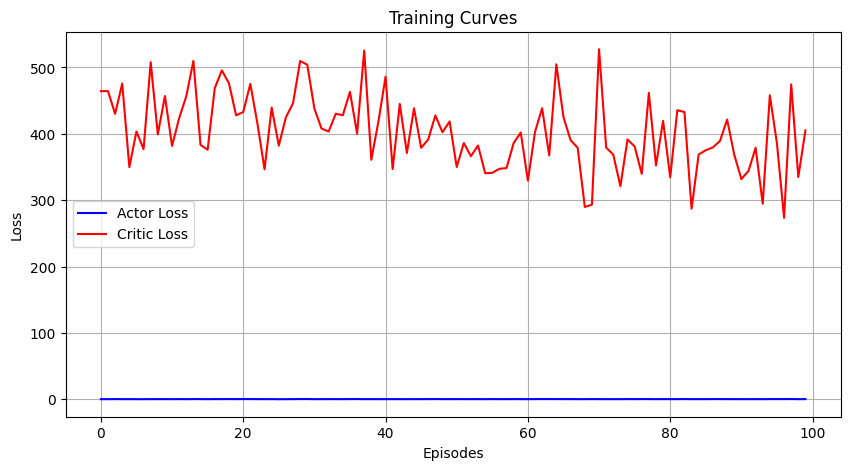

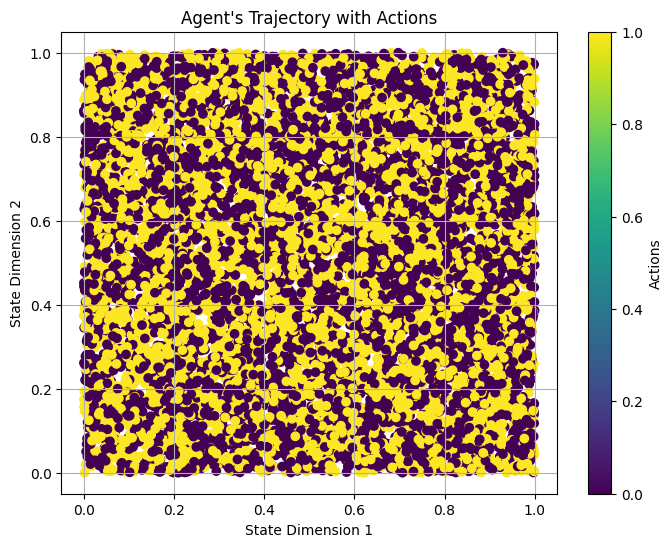

In [ ]:
import matplotlib.pyplot as plt

# Training with Trajectory Visualization
environment = Environment()
actor_critic = ActorCriticNetwork(state_size=environment.state_size, action_size=environment.action_size, entropy_weight=0.1)  # Starting with a higher entropy weight
num_episodes = 100
actor_losses = []
critic_losses = []
trajectory_states = []
trajectory_actions = []

initial_entropy_weight = 0.1
final_entropy_weight = 0.01
entropy_weight_decay = (initial_entropy_weight - final_entropy_weight) / num_episodes

for episode in range(num_episodes):
    states = []
    actions = []
    rewards = []
    next_states = []
    total_episode_reward = 0
    state = environment.reset()
    max_steps_per_episode = 100

    # Update entropy weight
    actor_critic.entropy_weight -= entropy_weight_decay

    for t in range(max_steps_per_episode):
        action_probs, _ = actor_critic.forward(state)
        action = torch.multinomial(action_probs, 1)
        next_state, reward, done = environment.step(action)

        # Record trajectory states and actions
        trajectory_states.append(state.numpy())
        trajectory_actions.append(action.item())

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_state)
        total_episode_reward += reward

        state = next_state

        if done:
            break

    returns = compute_returns(rewards)
    next_state_values = actor_critic.forward(torch.stack(next_states))[1]
    advantages = compute_advantages(rewards, next_state_values)

    actor_loss, critic_loss = actor_critic.train_step(torch.stack(states), torch.stack(actions), returns, advantages)
    actor_losses.append(actor_loss)
    critic_losses.append(critic_loss)
    average_episode_reward = total_episode_reward / len(rewards)

    if episode % 10 == 0:
        print(f"Episode {episode}: Actor Loss = {actor_loss}, Critic Loss = {critic_loss}, Average Reward = {average_episode_reward:.2f}")

# Plot training curves
plot_training_curves(actor_losses, critic_losses)

# Plot trajectory
trajectory_states = np.array(trajectory_states)
trajectory_actions = np.array(trajectory_actions)

plt.figure(figsize=(8, 6))
plt.scatter(trajectory_states[:, 0], trajectory_states[:, 1], c=trajectory_actions, cmap='viridis', marker='o')
plt.colorbar(label='Actions')
plt.title('Agent\'s Trajectory with Actions')
plt.xlabel('State Dimension 1')
plt.ylabel('State Dimension 2')
plt.grid(True)
plt.show()
